In [2]:
# Import all libraries we need for the whole notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import xgboost as xgb

print("All libraries loaded successfully")

All libraries loaded successfully


In [3]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['Class'].value_counts())
print("\nFraud percentage:")
print(df['Class'].value_counts(normalize=True) * 100)

Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum().sum())

# Look at the Amount column
print("\nTransaction Amount stats:")
print(df['Amount'].describe())

# Look at a few fraud transactions
print("\nSample fraud transactions:")
print(df[df['Class']==1][['Amount','Class']].head(10))

Missing values:
0

Transaction Amount stats:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Sample fraud transactions:
      Amount  Class
541     0.00      1
623   529.00      1
4920  239.93      1
6108   59.00      1
6329    1.00      1
6331    1.00      1
6334    1.00      1
6336    1.00      1
6338    1.00      1
6427    1.00      1


In [5]:
# Separate inputs and output
X = df.drop('Class', axis=1)  # everything except Class
y = df['Class']                # just the Class column

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # this makes sure both train and test have same fraud ratio
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nFraud cases in training:", y_train.sum())
print("Fraud cases in test:", y_test.sum())

Training set size: (227845, 30)
Test set size: (56962, 30)

Fraud cases in training: 394
Fraud cases in test: 98


In [6]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

# Predict on test data
dt_predictions = dt_model.predict(X_test)

# Evaluate
print("=" * 40)
print("DECISION TREE RESULTS")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, dt_predictions) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, dt_predictions) * 100:.2f}%")
print(f"Recall:    {recall_score(y_test, dt_predictions) * 100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, dt_predictions) * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))

DECISION TREE RESULTS
Accuracy:  99.94%
Precision: 84.62%
Recall:    78.57%
F1 Score:  81.48%

Confusion Matrix:
[[56850    14]
 [   21    77]]


In [10]:
# Random Forest WITH class weights
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)
rf_balanced.fit(X_train, y_train)

# Predict
rf_balanced_predictions = rf_balanced.predict(X_test)

# Evaluate
print("=" * 50)
print("RANDOM FOREST - WITH CLASS WEIGHTS")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, rf_balanced_predictions) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, rf_balanced_predictions) * 100:.2f}%")
print(f"Recall:    {recall_score(y_test, rf_balanced_predictions) * 100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, rf_balanced_predictions) * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_balanced_predictions))

# Calculate missed fraudsters cleanly
missed = (y_test == 1).sum() - (rf_balanced_predictions[y_test == 1] == 1).sum()

print("\n" + "=" * 50)
print("COMPARISON")
print("=" * 50)
print(f"Precision  — Before: 95.06%   After: {precision_score(y_test, rf_balanced_predictions)*100:.2f}%")
print(f"Recall     — Before: 78.57%   After: {recall_score(y_test, rf_balanced_predictions)*100:.2f}%")
print(f"F1 Score   — Before: 86.03%   After: {f1_score(y_test, rf_balanced_predictions)*100:.2f}%")
print(f"Missed fraud cases — Before: 21   After: {missed}")

RANDOM FOREST - WITH CLASS WEIGHTS
Accuracy:  99.89%
Precision: 64.84%
Recall:    84.69%
F1 Score:  73.45%

Confusion Matrix:
[[56819    45]
 [   15    83]]

COMPARISON
Precision  — Before: 95.06%   After: 64.84%
Recall     — Before: 78.57%   After: 84.69%
F1 Score   — Before: 86.03%   After: 73.45%
Missed fraud cases — Before: 21   After: 15


In [7]:
# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

# Predict
xgb_predictions = xgb_model.predict(X_test)

# Evaluate
print("=" * 40)
print("XGBOOST RESULTS")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, xgb_predictions) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, xgb_predictions) * 100:.2f}%")
print(f"Recall:    {recall_score(y_test, xgb_predictions) * 100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, xgb_predictions) * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_predictions))

XGBOOST RESULTS
Accuracy:  99.95%
Precision: 91.67%
Recall:    78.57%
F1 Score:  84.62%

Confusion Matrix:
[[56857     7]
 [   21    77]]


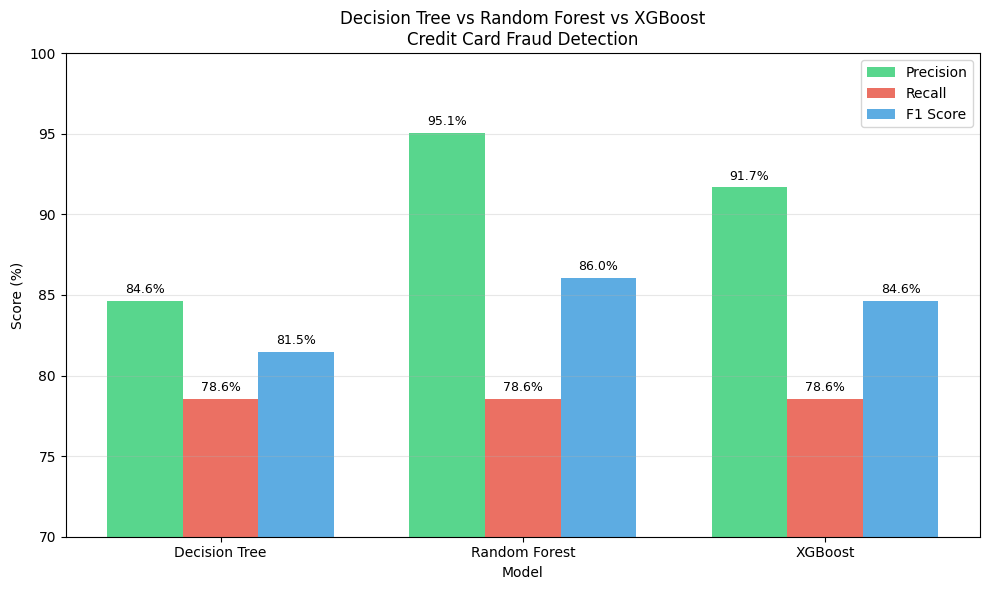

In [8]:
# Visual comparison of all three models
models = ['Decision Tree', 'Random Forest', 'XGBoost']
precision = [84.62, 95.06, 91.67]
recall = [78.57, 78.57, 78.57]
f1 = [81.48, 86.03, 84.62]

x = range(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar([i - width for i in x], precision, width,
                label='Precision', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x, recall, width,
                label='Recall', color='#e74c3c', alpha=0.8)
bars3 = ax.bar([i + width for i in x], f1, width,
                label='F1 Score', color='#3498db', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Score (%)')
ax.set_title('Decision Tree vs Random Forest vs XGBoost\nCredit Card Fraud Detection')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(70, 100)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in [bars1, bars2, bars3]:
    for rect in bar:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + 0.3,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
# Install the library that contains SMOTE
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

print("SMOTE ready")

SMOTE ready


In [12]:
# Step 1 - Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check what SMOTE did
print("Before SMOTE:")
print(f"Fraud cases in training: {y_train.sum()}")
print(f"Legitimate cases in training: {(y_train == 0).sum()}")

print("\nAfter SMOTE:")
print(f"Fraud cases in training: {y_train_smote.sum()}")
print(f"Legitimate cases in training: {(y_train_smote == 0).sum()}")

Before SMOTE:
Fraud cases in training: 394
Legitimate cases in training: 227451

After SMOTE:
Fraud cases in training: 227451
Legitimate cases in training: 227451


In [13]:
# Train Random Forest on SMOTE balanced data block 12
rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)
rf_smote.fit(X_train_smote, y_train_smote)

# Predict on REAL test data — no SMOTE here
rf_smote_predictions = rf_smote.predict(X_test)

# Evaluate
print("=" * 50)
print("RANDOM FOREST + SMOTE")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, rf_smote_predictions) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, rf_smote_predictions) * 100:.2f}%")
print(f"Recall:    {recall_score(y_test, rf_smote_predictions) * 100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, rf_smote_predictions) * 100:.2f}%")

missed = (y_test == 1).sum() - (rf_smote_predictions[y_test == 1] == 1).sum()
print(f"\nMissed fraudsters: {missed}")
print(f"Caught fraudsters: {(y_test == 1).sum() - missed} out of {(y_test == 1).sum()}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_smote_predictions))

RANDOM FOREST + SMOTE
Accuracy:  99.71%
Precision: 35.95%
Recall:    88.78%
F1 Score:  51.18%

Missed fraudsters: 11
Caught fraudsters: 87 out of 98

Confusion Matrix:
[[56709   155]
 [   11    87]]


In [14]:
# XGBoost on SMOTE balanced data
xgb_smote = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_smote.fit(X_train_smote, y_train_smote)

# Predict on REAL test data
xgb_smote_predictions = xgb_smote.predict(X_test)

# Evaluate
print("=" * 50)
print("XGBOOST + SMOTE")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, xgb_smote_predictions) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, xgb_smote_predictions) * 100:.2f}%")
print(f"Recall:    {recall_score(y_test, xgb_smote_predictions) * 100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, xgb_smote_predictions) * 100:.2f}%")

missed = (y_test == 1).sum() - (xgb_smote_predictions[y_test == 1] == 1).sum()
print(f"\nMissed fraudsters: {missed}")
print(f"Caught fraudsters: {(y_test == 1).sum() - missed} out of {(y_test == 1).sum()}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_smote_predictions))

XGBOOST + SMOTE
Accuracy:  99.57%
Precision: 27.41%
Recall:    89.80%
F1 Score:  42.00%

Missed fraudsters: 10
Caught fraudsters: 88 out of 98

Confusion Matrix:
[[56631   233]
 [   10    88]]


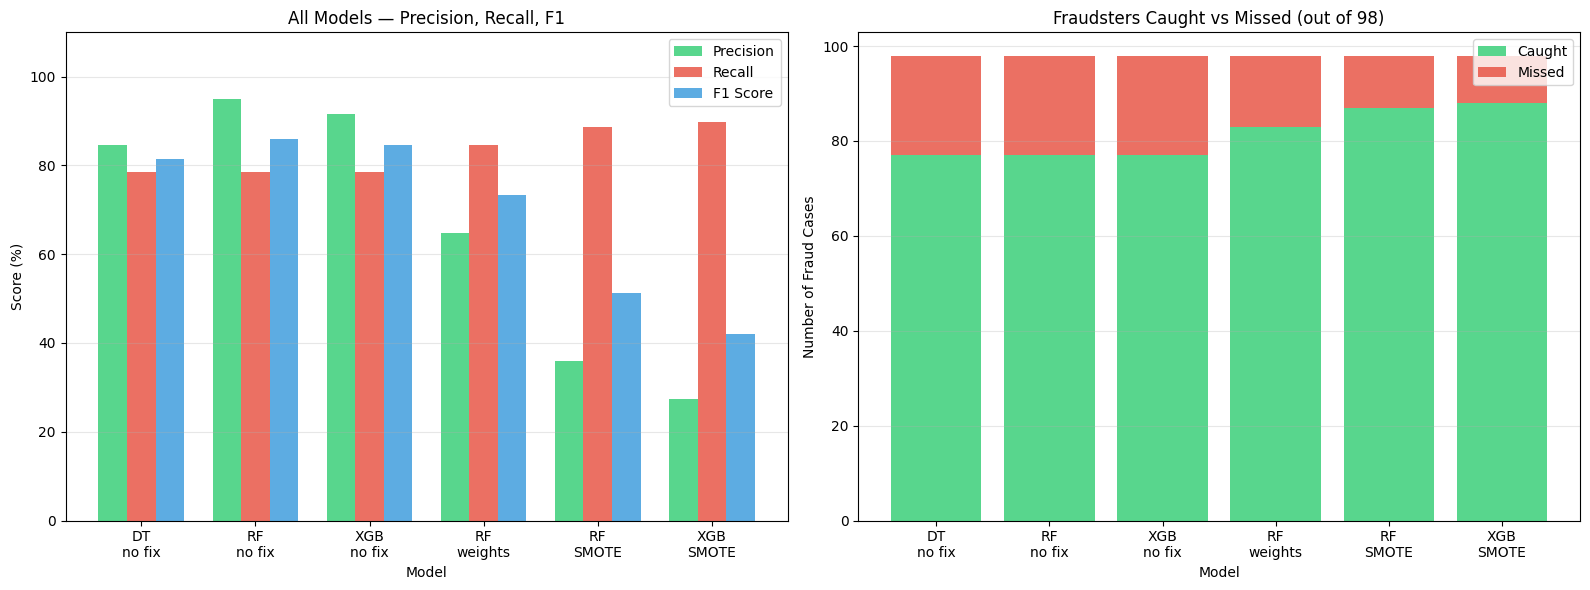

In [15]:
# Final comparison chart - all 6 models
models = ['DT\nno fix', 'RF\nno fix', 'XGB\nno fix',
          'RF\nweights', 'RF\nSMOTE', 'XGB\nSMOTE']

recall =    [78.57, 78.57, 78.57, 84.69, 88.78, 89.80]
precision = [84.62, 95.06, 91.67, 64.84, 35.95, 27.41]
f1 =        [81.48, 86.03, 84.62, 73.45, 51.18, 42.00]

x = range(len(models))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left chart - all three metrics
bars1 = ax1.bar([i - width for i in x], precision, width,
                label='Precision', color='#2ecc71', alpha=0.8)
bars2 = ax1.bar(x, recall, width,
                label='Recall', color='#e74c3c', alpha=0.8)
bars3 = ax1.bar([i + width for i in x], f1, width,
                label='F1 Score', color='#3498db', alpha=0.8)

ax1.set_xlabel('Model')
ax1.set_ylabel('Score (%)')
ax1.set_title('All Models — Precision, Recall, F1')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylim(0, 110)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Right chart - fraudsters caught vs missed
caught =       [77, 77, 77, 83, 87, 88]
missed =       [21, 21, 21, 15, 11, 10]

ax2.bar(x, caught, label='Caught', color='#2ecc71', alpha=0.8)
ax2.bar(x, missed, bottom=caught, label='Missed', color='#e74c3c', alpha=0.8)
ax2.set_xlabel('Model')
ax2.set_ylabel('Number of Fraud Cases')
ax2.set_title('Fraudsters Caught vs Missed (out of 98)')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# BUSINESS DECISION FRAMEWORK
# Credit Card Fraud Detection — Model Selection Guide
# ============================================================

def recommend_model(priority):
    """
    Recommends the best fraud detection model
    based on business priority.

    Parameters:
    priority: 'customer_experience', 'fraud_prevention', 'balanced'
    """

    models = {
        'RF_no_fix':      {'recall': 78.57, 'precision': 95.06,
                           'f1': 86.03, 'caught': 77,
                           'false_alarms': 4},
        'RF_weights':     {'recall': 84.69, 'precision': 64.84,
                           'f1': 73.45, 'caught': 83,
                           'false_alarms': 45},
        'RF_SMOTE':       {'recall': 88.78, 'precision': 35.95,
                           'f1': 51.18, 'caught': 87,
                           'false_alarms': 155},
        'XGBoost_SMOTE':  {'recall': 89.80, 'precision': 27.41,
                           'f1': 42.00, 'caught': 88,
                           'false_alarms': 233},
    }

    fraud_loss_per_case = 500      # €500 average fraud loss
    false_alarm_cost    = 5        # €5 support cost per false alarm
    total_fraud_cases   = 98

    print("=" * 60)
    print("BUSINESS DECISION FRAMEWORK")
    print("Credit Card Fraud Detection — Model Recommendation")
    print("=" * 60)

    if priority == 'customer_experience':
        model = 'RF_no_fix'
        print("\n🏦 SCENARIO: Small bank / Fintech startup")
        print("Priority: Customer experience over fraud prevention")
        print("Reason: Cannot afford angry customers blocking cards")

    elif priority == 'fraud_prevention':
        model = 'XGBoost_SMOTE'
        print("\n🏦 SCENARIO: Large bank / High volume payment gateway")
        print("Priority: Catch maximum fraud, minimise financial loss")
        print("Reason: Fraud losses far outweigh false alarm costs")

    elif priority == 'balanced':
        model = 'RF_weights'
        print("\n🏦 SCENARIO: Mid-size bank / Insurance company")
        print("Priority: Balance fraud prevention and customer experience")
        print("Reason: Both false alarms and missed fraud are costly")

    else:
        print("Invalid priority. Choose: customer_experience, fraud_prevention, balanced")
        return

    m = models[model]

    # Calculate business impact
    fraudsters_caught  = m['caught']
    fraudsters_missed  = total_fraud_cases - fraudsters_caught
    money_saved        = fraudsters_caught  * fraud_loss_per_case
    money_lost         = fraudsters_missed  * fraud_loss_per_case
    false_alarm_costs  = m['false_alarms']  * false_alarm_cost
    net_benefit        = money_saved - money_lost - false_alarm_costs

    print(f"\n✅ RECOMMENDED MODEL: {model}")
    print(f"\n📊 MODEL PERFORMANCE:")
    print(f"   Recall:        {m['recall']}%")
    print(f"   Precision:     {m['precision']}%")
    print(f"   F1 Score:      {m['f1']}%")
    print(f"\n💰 BUSINESS IMPACT:")
    print(f"   Fraudsters caught:     {fraudsters_caught} out of {total_fraud_cases}")
    print(f"   Fraudsters missed:     {fraudsters_missed}")
    print(f"   Money saved:           €{money_saved:,}")
    print(f"   Money lost to fraud:   €{money_lost:,}")
    print(f"   False alarm costs:     €{false_alarm_costs:,}")
    print(f"   ─────────────────────────────")
    print(f"   Net benefit:           €{net_benefit:,}")
    print("=" * 60)

# ============================================================
# RUN ALL THREE SCENARIOS
# ============================================================

recommend_model('customer_experience')
print()
recommend_model('fraud_prevention')
print()
recommend_model('balanced')

BUSINESS DECISION FRAMEWORK
Credit Card Fraud Detection — Model Recommendation

🏦 SCENARIO: Small bank / Fintech startup
Priority: Customer experience over fraud prevention
Reason: Cannot afford angry customers blocking cards

✅ RECOMMENDED MODEL: RF_no_fix

📊 MODEL PERFORMANCE:
   Recall:        78.57%
   Precision:     95.06%
   F1 Score:      86.03%

💰 BUSINESS IMPACT:
   Fraudsters caught:     77 out of 98
   Fraudsters missed:     21
   Money saved:           €38,500
   Money lost to fraud:   €10,500
   False alarm costs:     €20
   ─────────────────────────────
   Net benefit:           €27,980

BUSINESS DECISION FRAMEWORK
Credit Card Fraud Detection — Model Recommendation

🏦 SCENARIO: Large bank / High volume payment gateway
Priority: Catch maximum fraud, minimise financial loss
Reason: Fraud losses far outweigh false alarm costs

✅ RECOMMENDED MODEL: XGBoost_SMOTE

📊 MODEL PERFORMANCE:
   Recall:        89.8%
   Precision:     27.41%
   F1 Score:      42.0%

💰 BUSINESS IMPACT:
